Loading and preparing data...
Dataset shape after cleaning: (1352034, 31)

Performing feature engineering...

Factorizing 'TRANSPORT' column...
Transport categories: ['BUS', 'MINIBUS', 'MTR', 'BUS->BUS', 'MINIBUS->BUS', 'MTR->MINIBUS', 'MTR->BUS', 'BUS->MINIBUS', 'MINIBUS->MTR', 'BUS->MTR']
Final feature matrix shape: (1352034, 22)

Splitting data into train/test sets...


/var/folders/sg/hvr4hv7d1h56w4dn3njqrxh40000gn/T/ipykernel_32207/2023016418.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['TRANSPORT'], transport_categories = pd.factorize(X['TRANSPORT'])


Train size: 1081627, Test size: 270407

Setting up Random Forest model...

Training baseline Random Forest model...

Evaluating model performance...

Train Set Performance:
MSE: 9.1262
RMSE: 3.0210
MAE: 1.9172
R²: 0.8877

Test Set Performance:
MSE: 11.1212
RMSE: 3.3348
MAE: 2.1083
R²: 0.8631

Analyzing feature importance...

Top 10 Most Important Features:
                              Feature  Importance
0                           TRANSPORT    0.246782
1                            DISTANCE    0.240839
2                        PASS HARBOUR    0.115064
3                            NO_STOPS    0.066537
4  NEXT ESTIMATED EMPLOYED POPULATION    0.040273
5       ESTIMATED EMPLOYED POPULATION    0.031224
6                NEXT BUILDING NUMBER    0.022351
7              NEXT LIVING POPULATION    0.022221
8                 NEXT DENSITY_UNIQUE    0.021238
9                   LIVING POPULATION    0.019930


/var/folders/sg/hvr4hv7d1h56w4dn3njqrxh40000gn/T/ipykernel_32207/2023016418.py:130: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


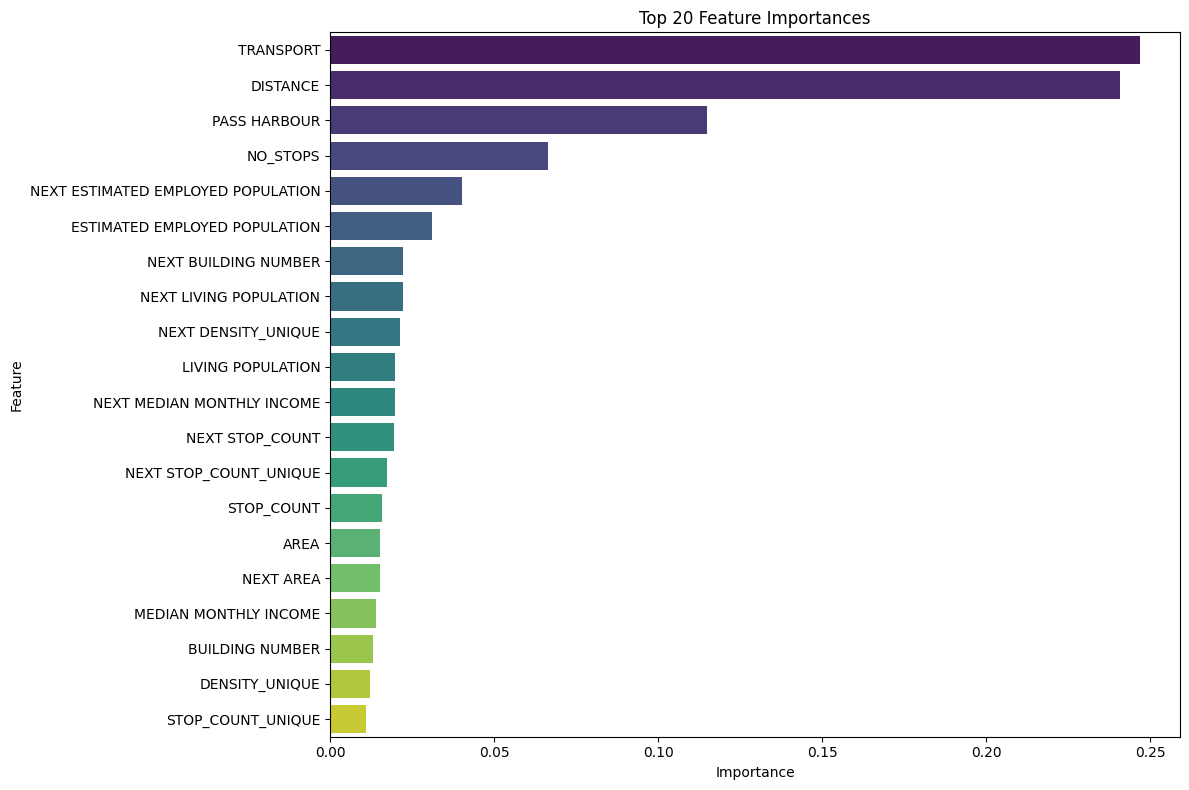


Training MSE: 9.1262
Test MSE: 11.1212


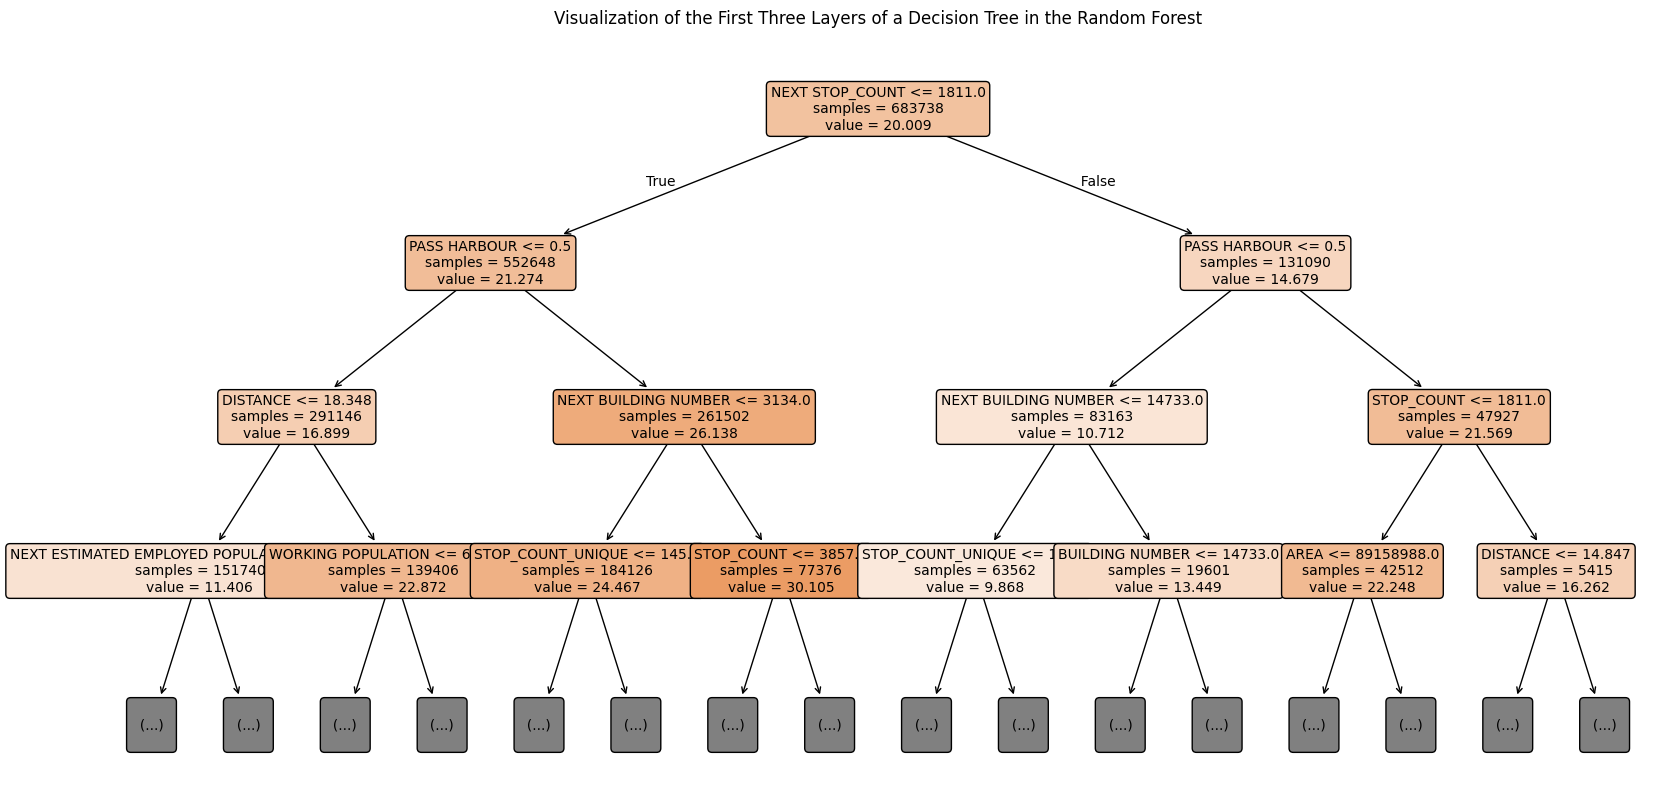

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load and Prepare Data
print("Loading and preparing data...")
data = pd.read_csv('../Data/final_transport_data.csv')

# Define variables
response_var = 'PRICE'
explanatory_vars = [
    # 'DISTRICT',
    # 'NEXT DISTRICT',
    'TRANSPORT',
    'NO_STOPS', 
    'DISTANCE', 
    'STOP_COUNT', 
    'STOP_COUNT_UNIQUE', 
    'AREA', 
    'DENSITY_UNIQUE', 
    'LIVING POPULATION', 
    'WORKING POPULATION', 
    'BUILDING NUMBER', 
    'ESTIMATED EMPLOYED POPULATION', 
    'MEDIAN MONTHLY INCOME', 
    'NEXT STOP_COUNT', 
    'NEXT STOP_COUNT_UNIQUE', 
    'NEXT AREA', 
    'NEXT DENSITY_UNIQUE', 
    'NEXT LIVING POPULATION', 
    'NEXT WORKING POPULATION', 
    'NEXT BUILDING NUMBER', 
    'NEXT ESTIMATED EMPLOYED POPULATION', 
    'NEXT MEDIAN MONTHLY INCOME', 
    'PASS HARBOUR'
]

# Clean data
data = data.dropna(axis=0)
print(f"Dataset shape after cleaning: {data.shape}")

# 2. Feature Engineering
print("\nPerforming feature engineering...")
X = data[explanatory_vars]
y = data[response_var]

# Factorize the 'TRANSPORT' column
if 'TRANSPORT' in X.columns:
    print("\nFactorizing 'TRANSPORT' column...")
    X['TRANSPORT'], transport_categories = pd.factorize(X['TRANSPORT'])
    print(f"Transport categories: {list(transport_categories)}")

# Convert other categorical variables (if any) to dummy variables
# turn District and Next District into variables (using one hot encoding)
# X = pd.get_dummies(X, columns=['DISTRICT', 'NEXT DISTRICT'], drop_first=True)
print(f"Final feature matrix shape: {X.shape}")

# 3. Train-Test Split
print("\nSplitting data into train/test sets...")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42
)
print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")

# 4. Random Forest Model Setup
print("\nSetting up Random Forest model...")
rf = RandomForestRegressor(
    n_estimators=200,  
    max_depth=20,
    min_samples_split=2,
    min_samples_leaf=2,  
    max_features='sqrt',
    random_state=42,
    n_jobs=-1  
) 

# 5. Train Random Forest Model
print("\nTraining baseline Random Forest model...")
rf.fit(X_train, y_train)

# 6. Model Evaluation
print("\nEvaluating model performance...")
y_pred_train = rf.predict(X_train)
y_pred = rf.predict(X_test)

# Calculate performance metrics
train_metrics = {
    'MSE': mean_squared_error(y_train, y_pred_train),
    'RMSE': np.sqrt(mean_squared_error(y_train, y_pred_train)),
    'MAE': mean_absolute_error(y_train, y_pred_train),
    'R²': r2_score(y_train, y_pred_train)
}
print("\nTrain Set Performance:")
for name, value in train_metrics.items():
    print(f"{name}: {value:.4f}")

metrics = {
    'MSE': mean_squared_error(y_test, y_pred),
    'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
    'MAE': mean_absolute_error(y_test, y_pred),
    'R²': r2_score(y_test, y_pred)
}

print("\nTest Set Performance:")
for name, value in metrics.items():
    print(f"{name}: {value:.4f}")

# 7. Feature Importance Analysis
print("\nAnalyzing feature importance...")
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

# Create feature importance dataframe
feature_importance = pd.DataFrame({
    'Feature': X.columns[indices],
    'Importance': importances[indices]
})

print("\nTop 10 Most Important Features:")
print(feature_importance.head(10))

# Visualize feature importance
plt.figure(figsize=(12, 8))
sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance.head(20),
    palette='viridis'
)
plt.title('Top 20 Feature Importances')
plt.tight_layout()
plt.show()  # Display the image


from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Plot the first three layers of the first tree in the Random Forest
plt.figure(figsize=(20, 10))
plot_tree(
    rf.estimators_[0],
    feature_names=X.columns,
    filled=True,
    rounded=True,
    fontsize=10,
    max_depth=3,  # Limit the visualization to the first three layers
    impurity=False,  # Exclude impurity (e.g., Gini or MSE)
    proportion=False  # Exclude proportions
)
plt.title("Visualization of the First Three Layers of a Decision Tree in the Random Forest")
plt.show()




In [9]:
# print the feature importance of all the features
print("\nFeature Importance of All Features:")
for i in range(len(importances)):
    print(f"{X.columns[i]}: {importances[i]:.4f}")



Feature Importance of All Features:
TRANSPORT: 0.2468
NO_STOPS: 0.0665
DISTANCE: 0.2408
STOP_COUNT: 0.0158
STOP_COUNT_UNIQUE: 0.0109
AREA: 0.0152
DENSITY_UNIQUE: 0.0122
LIVING POPULATION: 0.0199
WORKING POPULATION: 0.0106
BUILDING NUMBER: 0.0130
ESTIMATED EMPLOYED POPULATION: 0.0312
MEDIAN MONTHLY INCOME: 0.0141
NEXT STOP_COUNT: 0.0194
NEXT STOP_COUNT_UNIQUE: 0.0174
NEXT AREA: 0.0152
NEXT DENSITY_UNIQUE: 0.0212
NEXT LIVING POPULATION: 0.0222
NEXT WORKING POPULATION: 0.0097
NEXT BUILDING NUMBER: 0.0224
NEXT ESTIMATED EMPLOYED POPULATION: 0.0403
NEXT MEDIAN MONTHLY INCOME: 0.0199
PASS HARBOUR: 0.1151


In [5]:
test_results = pd.DataFrame({
    'y_true': y_test,
    'y_pred': y_pred,
    'DISTRICT': data.loc[X_test.index, 'DISTRICT'],  
    'NEXT DISTRICT': data.loc[X_test.index, 'NEXT DISTRICT']  
})

grouped_mse = test_results.groupby(['DISTRICT', 'NEXT DISTRICT']).apply(
    lambda group: mean_squared_error(group['y_true'], group['y_pred'])
).reset_index(name='MSE')

# Sort by MSE 
grouped_mse = grouped_mse.sort_values(by='MSE', ascending=False)  

# Print results
print("\nMSE by (DISTRICT, NEXT DISTRICT) groups:")
print(grouped_mse)

# Calculate trimmed mean of MSE
from scipy.stats import trim_mean  

mse_values = grouped_mse['MSE'].values

trimmed_mean_mse = trim_mean(mse_values, proportiontocut=0.05)

print(f"\nTrimmed Mean MSE (5%): {trimmed_mean_mse:.4f}")



MSE by (DISTRICT, NEXT DISTRICT) groups:
                         DISTRICT                NEXT DISTRICT         MSE
484                  Robin's Nest                Sha Tin North  326.666683
948                  Tai Po South                 Robin's Nest  290.360842
539                  Sha Tin East                 Robin's Nest  262.566128
483                  Robin's Nest                 Sha Tin East  261.770869
619                 Sha Tin South                 Robin's Nest  253.242832
...                           ...                          ...         ...
1349                      Western           Kowloon City North    0.000052
783   Southern District Northwest               Kwun Tong West    0.000052
707             Sham Shui Po East  Southern District Northwest    0.000038
456                Kwun Tong West  Southern District Northwest    0.000012
1221                Tuen Mun East                     Tsing Yi    0.000002

[1657 rows x 3 columns]

Trimmed Mean MSE (5%): 7.8447


/var/folders/sg/hvr4hv7d1h56w4dn3njqrxh40000gn/T/ipykernel_27198/4006851332.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped_mse = test_results.groupby(['DISTRICT', 'NEXT DISTRICT']).apply(


In [7]:
# 1. Filter groups where MSE > trimmed mean
high_mse_groups = grouped_mse[grouped_mse['MSE'] > trimmed_mean_mse].copy()

# 2. Convert to a list of dictionaries (one per group)
high_mse_list = high_mse_groups.to_dict('records')

# 3. Print first 5 as example
for group in high_mse_list[:5]:  
    print(f"{group['DISTRICT']} → {group['NEXT DISTRICT']}: MSE = {group['MSE']:.2f}")

# 4. print the number of pairs
print(f"Number of pairs exceeding trimmed mean of MSE: {len(high_mse_groups)}")


Robin's Nest → Sha Tin North: MSE = 326.67
Tai Po South → Robin's Nest: MSE = 290.36
Sha Tin East → Robin's Nest: MSE = 262.57
Robin's Nest → Sha Tin East: MSE = 261.77
Sha Tin South → Robin's Nest: MSE = 253.24
Number of pairs exceeding trimmed mean of MSE: 580
